In [1]:
from dataset import DexYCB
import smplx

layer_arg = {'create_global_orient': False, 'create_hand_pose': False, 'create_betas': False, 'create_transl': False}
mano = {'right': smplx.create("./smplx_models", 'mano', is_rhand=True, use_pca=False, flat_hand_mean=False, **layer_arg),
        'left': smplx.create("./smplx_models", 'mano', is_rhand=False, use_pca=False, flat_hand_mean=False, **layer_arg)}

/home/renkaiwen/.conda/envs/sl_vit/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Fix shapedirs bug of MANO


In [3]:
dataset_test = DexYCB("s0", "test")

In [5]:
# len(dataset_test), dataset_test[10]

# 'color_file', 'depth_file', 'label_file', 'intrinsics', 'ycb_ids', 'ycb_grasp_ind', 'mano_side', 'mano_betas', 'is_bop_target', 'is_grasp_target'
item = dataset_test[399]
img_path = item['color_file']
label_path = item['label_file']

In [6]:
import einops as eps
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
import pickle as pkl
from scipy.sparse import csc_matrix

mano_data = {}
with open("./smplx_models/mano/MANO_RIGHT.pkl", "rb") as f:
    mano_data["right"] = pkl.load(f, encoding='latin1')
with open("./smplx_models/mano/MANO_LEFT.pkl", "rb") as f:
    mano_data["left"] = pkl.load(f, encoding='latin1')

/tmp/ipykernel_25002/44427674.py:6: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  mano_data["right"] = pkl.load(f, encoding='latin1')
/tmp/ipykernel_25002/44427674.py:8: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  mano_data["left"] = pkl.load(f, encoding='latin1')


In [8]:
label = np.load(label_path)  # seg, pose_y, pose_m, joint_3d, joint_2d
hand_comp = torch.from_numpy(mano_data[item['mano_side']]['hands_components'].astype(np.float32))

pose, transl = eps.unpack(label['pose_m'], [(48,), (3,)], "b *")
pose = torch.from_numpy(pose)
pose[:,3:] = pose[:,3:] @ hand_comp
transl = torch.from_numpy(transl)

shape = torch.tensor(item['mano_betas'])[None,:]

In [9]:
output = mano[item['mano_side']](betas=shape,
                                 hand_pose=pose[:,3:],
                                 global_orient=pose[:,:3],
                                 transl=torch.zeros(1,3))

mesh = output.vertices[0]

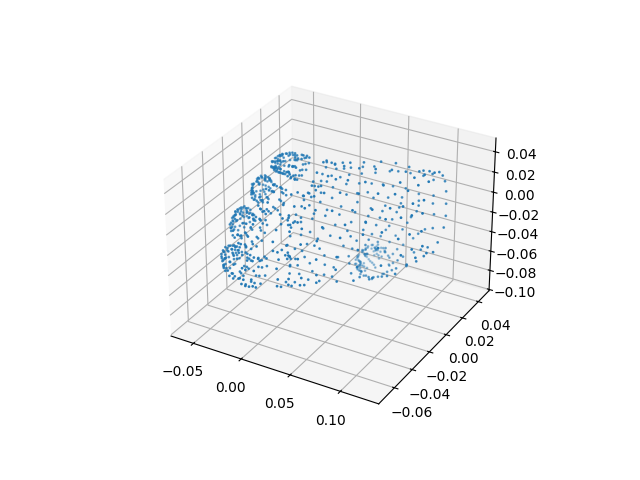

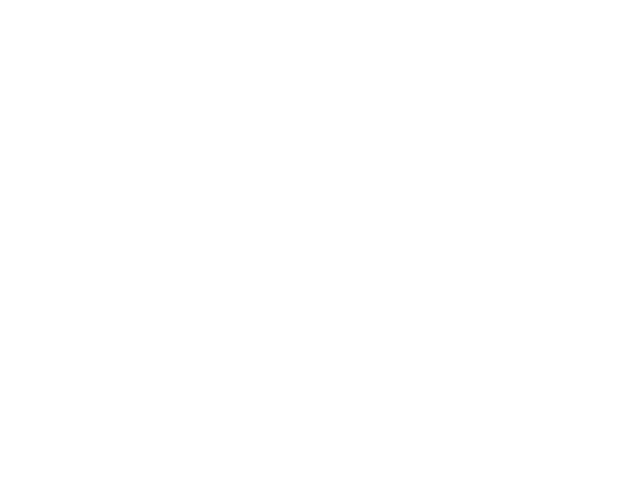

In [10]:
%matplotlib widget

plt.clf()
fig3d = plt.figure(0)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(mesh[:,0],mesh[:,1],mesh[:,2], s=1)
plt.show()

In [15]:
label['joint_2d'].shape

(1, 21, 2)

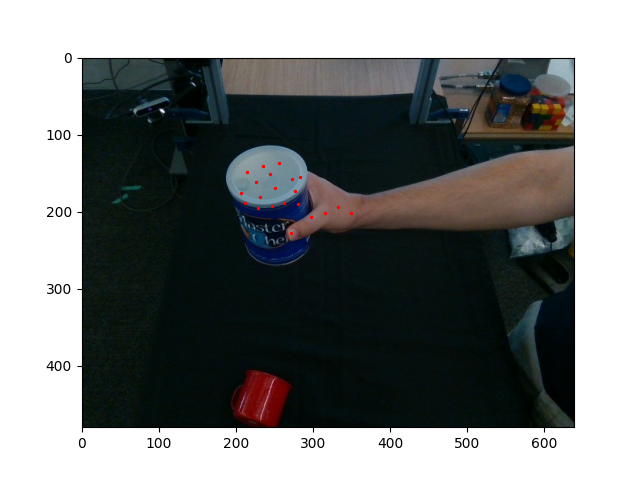

In [18]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.clf()
plt.imshow(img)
plt.scatter(label['joint_2d'][0,:,0],label['joint_2d'][0,:,1], c='r', s=2)
plt.show()